# KC judge cost research v001

## TL;DR

The strongest tested saving comes from sending fewer candidate pairs to the
judge, then using DeepSeek v4 Flash 0731 at low reasoning effort. On this
frozen, single-domain benchmark the conservative pair policy retained all 13
reviewed true composites while cutting calls from 522 to 257. Combined with
Flash-low, all 19 unambiguous benchmark cases were correct after candidate
filtering, with a projected full-rebuild judge cost of about $0.12 versus the
observed $2.98 rebuild.

This is evidence for a shadow rollout, not yet a domain-general promotion: the
corpus contains only Bag-of-Words material and just 13 positive pairs.

## Context & methods

We froze the current 145-KC corpus, every pairwise embedding similarity, the
current axes, 10 manually reviewed clean composite groups, one known false
composite, one ambiguous group, and the prior 10-pair prompt benchmark.

Primary guardrail: retain 100% of the 13 unambiguous true-composite pairs at
the candidate stage. Model configurations must introduce no false composites
and miss no true composites after candidate filtering. The ambiguous pair is
reported separately and excluded from promotion scoring.

The notebook recomputes candidate policies without API calls, reads the frozen
model-result JSON files, and projects full-rebuild cost from measured mean cost
per successful call. Cost projections are directional, not invoices: provider
routing and reasoning-token volume vary between calls.

In [1]:
from pathlib import Path
import json, sys
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from universe.judge_cost_eval import candidate_pairs, normalized_pair, score_candidate_policy

DATA = json.loads((ROOT / "evals/kc-judge-cost-v001.json").read_text())
RESULT_PATHS = {
    "Pro / high (current routing)": ROOT / "reports/kc-judge-cost-pro-high-v001.json",
    "Pro / reasoning disabled": ROOT / "reports/kc-judge-cost-pro-no-reasoning-v001.json",
    "Flash 0731 / high": ROOT / "reports/kc-judge-cost-flash-high-v001.json",
    "Flash 0731 / low": ROOT / "reports/kc-judge-cost-flash-low-v001.json",
}
RESULTS = {name: json.loads(path.read_text()) for name, path in RESULT_PATHS.items()}

HISTORICAL_REBUILD_COST = 2.97648492
HISTORICAL_CALLS = 522
HISTORICAL_PROMPT_COST = 0.36732708
HISTORICAL_COMPLETION_COST = 2.60915784

## Data

In [2]:
source_counts = Counter(item["source_id"] for item in DATA["items"])
case_counts = Counter(
    "ambiguous" if case["bucket"] == "ambiguous" else
    ("positive" if case["gold_merge"] else "negative")
    for case in DATA["cases"]
)
pd.DataFrame([
    {"metric": "KCs", "value": len(DATA["items"])},
    {"metric": "sources", "value": len(source_counts)},
    {"metric": "gold positive pairs", "value": case_counts["positive"]},
    {"metric": "gold negative pairs", "value": case_counts["negative"]},
    {"metric": "ambiguous pairs excluded", "value": case_counts["ambiguous"]},
])

,metric,value
0,KCs,145
1,sources,5
2,gold positive pairs,13
3,gold negative pairs,6
4,ambiguous pairs excluded,1


## Results — candidate generation

In [3]:
policy_specs = [
    ("Current", .70, 6, 5),
    ("Conservative", .80, 2, 3),
    ("Lean", .85, 1, 3),
    ("Lexical top-3 only", 1.01, 0, 3),
    ("Semantic only", .70, 6, 0),
    ("Lexical top-2 only", 1.01, 0, 2),
]
flash_low_mean = RESULTS["Flash 0731 / low"]["scores"]["mean_cost_per_call"]
rows = []
for name, floor, cap, lexical_k in policy_specs:
    pairs, _ = candidate_pairs(
        DATA, floor=floor, semantic_cap=cap, lexical_k=lexical_k
    )
    score = score_candidate_policy(DATA, pairs)
    rows.append({
        "policy": name,
        "floor": floor,
        "semantic_cap": cap,
        "lexical_k": lexical_k,
        "candidate_calls": score["candidate_count"],
        "calls_reduced": 1 - score["candidate_count"] / HISTORICAL_CALLS,
        "positive_recall": score["gold_positive_recall"],
        "known_negative_candidates": score["known_negative_candidates"],
        "projected_cost_historical_pro": score["candidate_count"] * HISTORICAL_REBUILD_COST / HISTORICAL_CALLS,
        "projected_cost_flash_low": score["candidate_count"] * flash_low_mean,
    })
policies = pd.DataFrame(rows)
policies.style.format({
    "calls_reduced": "{:.1%}", "positive_recall": "{:.1%}",
    "projected_cost_historical_pro": "${:.3f}",
    "projected_cost_flash_low": "${:.3f}",
})

,policy,floor,semantic_cap,lexical_k,candidate_calls,calls_reduced,positive_recall,known_negative_candidates,projected_cost_historical_pro,projected_cost_flash_low
0,Current,0.700000,6,5,522,0.0%,100.0%,3,$2.976,$0.235
1,Conservative,0.800000,2,3,257,50.8%,100.0%,1,$1.465,$0.116
2,Lean,0.850000,1,3,245,53.1%,100.0%,1,$1.397,$0.110
3,Lexical top-3 only,1.010000,0,3,240,54.0%,100.0%,1,$1.368,$0.108
4,Semantic only,0.700000,6,0,305,41.6%,92.3%,3,$1.739,$0.138
5,Lexical top-2 only,1.010000,0,2,169,67.6%,92.3%,1,$0.964,$0.076


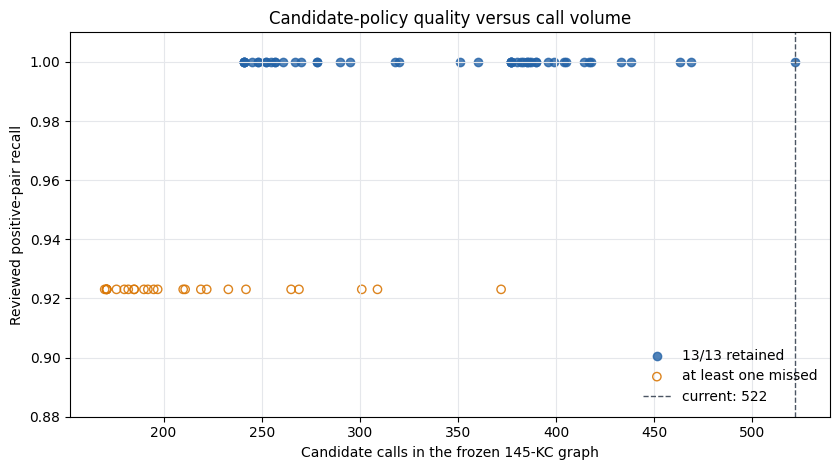

In [4]:
# Broader grid for an honest quality-vs-volume view (single-domain sample).
grid = []
for floor in [.70, .75, .80, .85, .90]:
    for cap in [1, 2, 3, 4, 6]:
        for lexical_k in [2, 3, 5]:
            pairs, _ = candidate_pairs(
                DATA, floor=floor, semantic_cap=cap, lexical_k=lexical_k
            )
            s = score_candidate_policy(DATA, pairs)
            grid.append({
                "floor": floor, "cap": cap, "lexical_k": lexical_k,
                "candidate_calls": s["candidate_count"],
                "positive_recall": s["gold_positive_recall"],
            })
grid = pd.DataFrame(grid).drop_duplicates()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
good = grid[grid.positive_recall == 1]
bad = grid[grid.positive_recall < 1]
ax.scatter(good.candidate_calls, good.positive_recall, color="#2463A7", label="13/13 retained", alpha=.8)
ax.scatter(bad.candidate_calls, bad.positive_recall, facecolors="none", edgecolors="#D97706", label="at least one missed", alpha=.9)
ax.axvline(522, color="#4B5563", linestyle="--", linewidth=1, label="current: 522")
ax.set(xlabel="Candidate calls in the frozen 145-KC graph", ylabel="Reviewed positive-pair recall", ylim=(.88, 1.01), title="Candidate-policy quality versus call volume")
ax.grid(axis="both", color="#E5E7EB", linewidth=.8)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## Results — model configurations

In [5]:
model_rows = []
for name, payload in RESULTS.items():
    s = payload["scores"]
    model_rows.append({
        "configuration": name,
        "scored_cases": s.get("scored_cases", s.get("successful_calls")),
        "failed_calls": s.get("failed_calls", 19 - s.get("successful_calls", 0)),
        "raw_merge_accuracy": s["merge_accuracy"],
        "false_merges": s["false_merges"],
        "missed_merges": s["missed_merges"],
        "direction_accuracy": s["direction_accuracy"],
        "measured_cost": s["total_cost"],
        "mean_cost_per_success": s["mean_cost_per_call"],
    })
models = pd.DataFrame(model_rows)
models.style.format({
    "raw_merge_accuracy": "{:.1%}", "direction_accuracy": "{:.1%}",
    "measured_cost": "${:.4f}", "mean_cost_per_success": "${:.6f}",
})

,configuration,scored_cases,failed_calls,raw_merge_accuracy,false_merges,missed_merges,direction_accuracy,measured_cost,mean_cost_per_success
0,Pro / high (current routing),17,2,76.5%,1,3,78.1%,$0.0241,$0.001420
1,Pro / reasoning disabled,15,4,66.7%,0,5,80.0%,$0.0234,$0.001557
2,Flash 0731 / high,19,0,94.7%,1,0,86.1%,$0.0132,$0.000694
3,Flash 0731 / low,19,0,94.7%,1,0,88.9%,$0.0086,$0.000451


In [6]:
def integrated_errors(payload, pairs):
    by_case = {row["case_id"]: row for row in payload["results"]}
    wrong = []
    for case in DATA["cases"]:
        if case["bucket"] != "gold":
            continue
        pair = normalized_pair(case["a"], case["b"])
        predicted = False
        if pair in pairs and by_case[case["id"]].get("parsed"):
            parsed = by_case[case["id"]]["parsed"]
            predicted = (
                parsed["verdict_a_to_b"] == "clear_yes"
                and parsed["verdict_b_to_a"] == "clear_yes"
            )
        if predicted != case["gold_merge"]:
            wrong.append(case["id"])
    return wrong

current_pairs, _ = candidate_pairs(DATA, floor=.70, semantic_cap=6, lexical_k=5)
recommended_pairs, _ = candidate_pairs(DATA, floor=.80, semantic_cap=2, lexical_k=3)
pd.DataFrame([
    {
        "configuration": name,
        "errors with current candidates": len(integrated_errors(payload, current_pairs)),
        "errors with conservative candidates": len(integrated_errors(payload, recommended_pairs)),
        "error ids after conservative filter": ", ".join(integrated_errors(payload, recommended_pairs)) or "none",
    }
    for name, payload in RESULTS.items()
    if payload["scores"].get("failed_calls", 0) == 0
])

,configuration,errors with current candidates,errors with conservative candidates,error ids after conservative filter
0,Flash 0731 / high,1,0,none
1,Flash 0731 / low,0,0,none


## Results — projected cost and incremental footprints

In [7]:
costs = pd.DataFrame([
    {"strategy": "Observed full rebuild (Pro)", "calls": 522, "projected_cost": HISTORICAL_REBUILD_COST, "benchmark_status": "observed cost"},
    {"strategy": "Conservative candidates + historical Pro cost/call", "calls": 257, "projected_cost": 257 * HISTORICAL_REBUILD_COST / 522, "benchmark_status": "13/13 candidate recall"},
    {"strategy": "Current candidates + Flash-low", "calls": 522, "projected_cost": 522 * flash_low_mean, "benchmark_status": "1 false merge"},
    {"strategy": "Conservative candidates + Flash-low", "calls": 257, "projected_cost": 257 * flash_low_mean, "benchmark_status": "19/19 integrated"},
])
costs.assign(savings_vs_observed=1-costs.projected_cost/HISTORICAL_REBUILD_COST).style.format({
    "projected_cost": "${:.3f}", "savings_vs_observed": "{:.1%}"
})

,strategy,calls,projected_cost,benchmark_status,savings_vs_observed
0,Observed full rebuild (Pro),522,$2.976,observed cost,0.0%
1,Conservative candidates + historical Pro cost/call,257,$1.465,13/13 candidate recall,50.8%
2,Current candidates + Flash-low,522,$0.235,1 false merge,92.1%
3,Conservative candidates + Flash-low,257,$0.116,19/19 integrated,96.1%


In [8]:
items = {item["id"]: item for item in DATA["items"]}
source_rows = []
for source_id, kc_count in source_counts.items():
    row = {"source_id": source_id, "kc_count": kc_count}
    for label, pairs in [("current", current_pairs), ("conservative", recommended_pairs)]:
        row[f"{label}_pairs_touching_source"] = sum(
            1 for a, b in pairs
            if items[a]["source_id"] == source_id or items[b]["source_id"] == source_id
        )
    source_rows.append(row)
source_footprints = pd.DataFrame(source_rows).sort_values("kc_count")
source_footprints

,source_id,kc_count,current_pairs_touching_source,conservative_pairs_touching_source
1,si-mod6-0022-a-simple-explanation-of-the-bag-o...,14,108,49
4,si-mod6-0026-atividade-bag-of-words,15,108,49
3,si-mod6-0025-getting-started-with-natural-lang...,29,163,78
0,si-mod6-0023-an-introduction-to-bag-of-words-a...,33,205,91
2,si-mod6-0024-representacao-vetorial-de-textos-...,54,272,135


## Takeaways

1. **Prune calls first.** The conservative two-channel policy (`cosine >= .80`,
   semantic top-2, lexical top-3) reduced the frozen full rebuild from 522 to
   257 calls while retaining all 13 reviewed true composites. Lexical top-3
   rescued one true pair below the semantic threshold, so semantic-only and
   lexical top-2 policies are rejected.
2. **Flash-low is the best tested model configuration, but only with the
   conservative candidate policy.** Raw judge output had one false merge; the
   upstream axes/candidate policy correctly removed it. The integrated frozen
   benchmark was 19/19 and the projected rebuild cost is about $0.12.
3. **Turning reasoning off on Pro is rejected.** It missed five positives among
   15 completed cases and suffered four provider rate-limit failures.
4. **Prompt trimming is not the first lever.** In the observed $2.98 rebuild,
   87.7% of judge cost was completion/reasoning. Removing task or answer context
   risks quality to chase the smaller cost component.
5. **Do not hard-promote from this corpus alone.** Shadow the conservative
   policy and Flash-low on the ingestion branch, add at least two unrelated
   subject areas to the gold set, and promote only if candidate recall remains
   100%, integrated false merges remain zero, and repeated critical cases are
   stable.